In [3]:
import os

class Graph:
    def __init__(self, n):
        self.maxNodes = n
        self.edgeList = []
        self.adj_list = []
        for i in range(0, n + 1):
            self.adj_list.append([])

    def add_edge(self, u, v):
        self.adj_list[u].append(v)
        self.adj_list[v].append(u)

        self.edgeList.append((u,v))


def read_edges_from_file(filename):
    with open(filename, 'r') as file:
        edges = [tuple(map(int, line.strip().split())) for line in file]
    return edges[0][0], edges[1:]

def create_graph_from_edges(edges, n):
    graph = Graph(n)
    for u, v in edges:
        graph.add_edge(u, v)
    return graph

In [4]:
from pyomo.environ import *
import networkx as nx

def ILP_Solver_Accurate(V, k, dist):
    model = ConcreteModel()

    # Variables
    vi = [(v, i) for v in V for i in range(1, k + 1)]
    model.x = Var(vi, domain=Binary, initialize=0)
    model.z = Var(domain=NonNegativeReals, bounds=(0, k), initialize=0)

    # Objective function
    model.Objective = Objective(expr=model.z, sense=minimize)

    # Constraints
    # Fractional coloring constraint
    model.unique_coloring = ConstraintList()
    for v in V:
        model.unique_coloring.add(sum(model.x[(v, i)] for i in range(1, k + 1)) == 1)

    # Adjacent coloring constraint
    model.adjacent_coloring = ConstraintList()
    for v in V:
        for u in V:
            for i in range(1, k + 1):
                if dist[u][v] <= i and u != v:
                    model.adjacent_coloring.add(model.x[(v, i)] + model.x[(u, i)] <= 1)

    # Coloring constraint
    model.coloring_constraint = ConstraintList()
    for v in V:
        for i in range(1, k + 1):
            model.coloring_constraint.add(i * model.x[(v, i)] <= model.z)

    # Solve
    solverFactory = SolverFactory('glpk')
    solverFactory._version_timeout = 600
    results = solverFactory.solve(model)
    
    # Return results
    return model.x, model.z, model, results

In [5]:
def get_distance_matrix_lol(g : Graph):
    G = nx.Graph()
    G.add_edges_from(g.edgeList)
    return nx.floyd_warshall(G)


In [6]:
def read_graphs_from_file():
    folder_path = '../generatedgraphs'  # Update this with the path to your folder
    graph_files = [file for file in os.listdir(folder_path) if file.endswith('.txt')]

    graphs = []
    for file in graph_files:
        n, edges = read_edges_from_file(os.path.join(folder_path, file))
        graph = create_graph_from_edges(edges, n)  # Replace n with the appropriate value
        graphs.append(graph)

    return graphs

In [7]:
graphs = read_graphs_from_file()

In [8]:
len(graphs)

31

In [9]:
n, edges = read_edges_from_file(os.path.join("../generatedgraphs", "56nodes.txt"))

In [ ]:
G = nx.Graph()
G.add_edges_from(graphs[0].edgeList)
nx.draw(G, with_labels=True, font_weight='bold', pos = nx.spring_layout(G), font_color='white', node_color='black', node_size=500)

In [ ]:
CHECK = graphs[0]

dist = get_distance_matrix_lol(CHECK)
v = [i for i in range(1, CHECK.maxNodes + 1)]
k = CHECK.maxNodes + 1

x, z, model, results = ILP_Solver_Accurate(v, k, dist)

In [ ]:
z()

In [ ]:
from rich.table import Table
table = Table(title="Total Colors Used")

table.add_column("Node Number")
table.add_column("Used Color")
for idx in x:
    if x[idx]() == 1:
        table.add_row(str(idx[0]), str(idx[1]))

In [ ]:
table

In [ ]:
def ILP_Solver_Approximate(V, k, dist):
    model = ConcreteModel()

    # Variables
    vi = [(v, i) for v in V for i in range(1, k + 1)]
    model.x = Var(vi, domain=NonNegativeReals, initialize=0, bounds=(0, 1))
    model.z = Var(domain=NonNegativeReals, bounds=(0, k), initialize=0)

    # Objective function
    model.Objective = Objective(expr=model.z, sense=minimize)

    # Constraints
    # Fractional coloring constraint
    model.unique_coloring = ConstraintList()
    for v in V:
        model.unique_coloring.add(sum(model.x[(v, i)] for i in range(1, k + 1)) == 1)

    # Adjacent coloring constraint
    model.adjacent_coloring = ConstraintList()
    for v in V:
        for u in V:
            for i in range(1, k + 1):
                if dist[u][v] <= i and u != v:
                    model.adjacent_coloring.add(model.x[(v, i)] + model.x[(u, i)] <= 1)

    # Coloring constraint
    model.coloring_constraint = ConstraintList()
    for v in V:
        for i in range(1, k + 1):
            model.coloring_constraint.add(i * model.x[(v, i)] <= model.z)

    # Solve
    solverFactory = SolverFactory('glpk')
    solverFactory._version_timeout = 600
    results = solverFactory.solve(model)
    
    # Return results
    return model.x, model.z, model, results

In [ ]:
g56 = create_graph_from_edges(edges, n)

In [ ]:
V = [i for i in range(1, g56.maxNodes + 1)]
k = g56.maxNodes
mat = get_distance_matrix_lol(g56)
x, z, problem, results = ILP_Solver_Approximate(V, k, mat)

In [ ]:
print(f"Objective value (z): {z()}\n")

In [ ]:
results.write()

In [ ]:
from tqdm import tqdm
import pandas as pd
import csv

fieldnames = ['Nodes', 'Number of colors used', 'File Name']
count: int = 1

for graph in tqdm(graphs):

    V = [i for i in range(1, graph.maxNodes + 1)]
    k = graph.maxNodes
    mat = get_distance_matrix_lol(graph)
    x, z, problem, results = ILP_Solver_Accurate(V, k, mat)
    file_name = f"status_graph_id_{count}.txt"


    with open('output.csv', 'a', newline='') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        if csvfile.tell() == 0:
            writer.writeheader()
        writer.writerow({'Nodes': graph.maxNodes, 'Number of colors used': z(), 'File Name': file_name})


    with open(file_name, "w") as file:
        file.write(f"Objective value (z): {z()}\n")

        file.write(f"Proper Coloring:\n")
        coloring = {}

        for idx in x:
            if x[idx]() == 1:
                file.write(f"node → {idx[0]}: color → {idx[1]}\n")

        json_repr = results.json_repn()
        
        file.write("\n\nProblem:\n")
        for key, value in json_repr["Problem"][0].items():
            file.write(f"{key}: {value}\n")
        file.write("\nSolver:\n")
        for key, value in json_repr["Solver"][0].items():
            if isinstance(value, dict):
                file.write(key + ":\n")
                for k, v in value.items():
                    file.write(f"  {k}: {v}\n")
            else:
                file.write(f"{key}: {value}\n")
        file.write("\nSolution:\n")
        for key, value in json_repr["Solution"][0].items():
            file.write(f"{key}: {value}\n")

    count += 1

In [ ]:
from rich.console import Console

console = Console()

df = pd.read_csv('output.csv')
console.print(df)

In [ ]:
import pandas as pd

df = pd.read_csv('output.csv')

In [ ]:
import pandas as pd


v1 = []

for index, row in df.iterrows():
    v1.append((row['Nodes'], row['Number of colors used']))

In [ ]:
df = pd.read_csv('greedy.csv', index_col=False)

v2 = []

for index, row in df.iterrows():
    v2.append((row['Nodes'], row['Total Colors Used']))

In [ ]:
for i in range(len(v1)):
    print(f"Nodes = {v1[i][0]}, ILP = {v1[i][1]}, Greedy = {v2[i][1]}")

In [ ]:
d4b_small = pd.read_csv("../stastistics/stats.csv", sep=',', index_col=False)
d4b_small["leaves/ratio"] = d4b_small["Total Leaves"] / d4b_small["Nodes"] * 100

d4b_small

In [ ]:
with open("edges.txt", "w") as f:
    f.write(f"{len(graphs)}\n")

for graph in graphs:
    with open("edges.txt", "a") as f:
        f.write(str(graph.maxNodes) + " " + str(len(graph.edgeList)) + "\n")
        edges = graph.edgeList
        for edge in edges:
            f.write(f"{edge[0]} {edge[1]}\n")

In [ ]:
bad_g = graphs[9]
bad_g.maxNodes # 8 colors in greedy and 4 colors in Exact

In [ ]:
import networkx as nx
G = nx.Graph()
G.add_edges_from(bad_g.edgeList)
nx.draw(G, with_labels=True)

In [ ]:
# 3d condition

import random, time

random.seed(int(time.time() * 1000))

ns = [random.randint(10000, 50000) for _ in range(65)]
ns = [n if n % 2 == 0 else n + 1 for n in ns]

with open("edges.txt", "w") as file:
    file.write(f"{len(ns)}\n")
    for n in ns:
        file.write(f"{n} {n - 1}\n")
        file.write("1 2\n")
        for i in range(2, n + 1, 2):
            if i > n or i + 1 > n or i + 2 > n:
                break
            
            file.write(f"{i} {i + 1}\n")
            file.write(f"{i} {i + 2}\n")

In [74]:
G = nx.Graph()

n : int = 1000

G.add_edge(1,2)
for i in range(2, n + 1, 2):
    if i > n or i + 1 > n or i + 2 > n:
        break
    G.add_edge(i, i + 1)
    G.add_edge(i, i + 2)


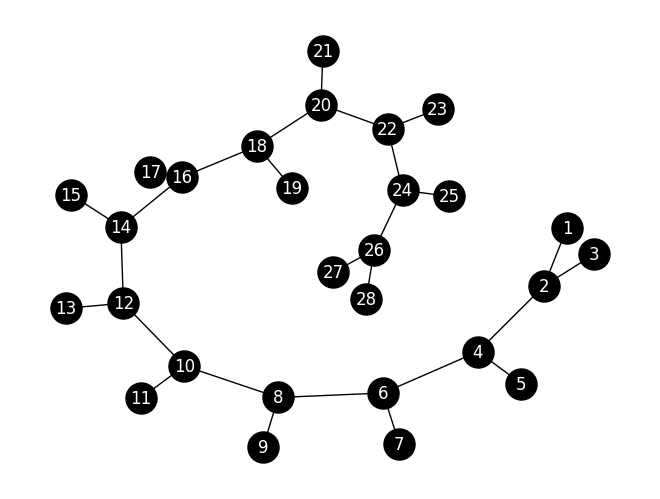

In [58]:
nx.draw(G, with_labels=True, pos = nx.spring_layout(G), font_color='white', node_color='black', node_size=500)

In [69]:
dist = nx.floyd_warshall(G)
V = [i for i in range(1, n + 1)]
k = n + 1
x, z, model, results = ILP_Solver_Accurate(V, k, dist)

In [71]:
z()

5.0

In [73]:
print("Nodes, Color ID")
for idx in x:
    if x[idx]() == 1:
        print(str(idx[0]), str(idx[1]))

Nodes, Color ID
1 5
2 3
3 2
4 1
5 2
6 4
7 1
8 1
9 2
10 3
11 1
12 1
13 2
14 5
15 1
16 1
17 3
18 2
19 1
20 1
21 3
22 4
23 1
24 1
25 2
26 3
27 1
28 5


In [75]:
edges = G.edges()
print(len(G.nodes()), len(G.edges()))
for e in edges:
    print(e[0], e[1])

1000 999
1 2
2 3
2 4
4 5
4 6
6 7
6 8
8 9
8 10
10 11
10 12
12 13
12 14
14 15
14 16
16 17
16 18
18 19
18 20
20 21
20 22
22 23
22 24
24 25
24 26
26 27
26 28
28 29
28 30
30 31
30 32
32 33
32 34
34 35
34 36
36 37
36 38
38 39
38 40
40 41
40 42
42 43
42 44
44 45
44 46
46 47
46 48
48 49
48 50
50 51
50 52
52 53
52 54
54 55
54 56
56 57
56 58
58 59
58 60
60 61
60 62
62 63
62 64
64 65
64 66
66 67
66 68
68 69
68 70
70 71
70 72
72 73
72 74
74 75
74 76
76 77
76 78
78 79
78 80
80 81
80 82
82 83
82 84
84 85
84 86
86 87
86 88
88 89
88 90
90 91
90 92
92 93
92 94
94 95
94 96
96 97
96 98
98 99
98 100
100 101
100 102
102 103
102 104
104 105
104 106
106 107
106 108
108 109
108 110
110 111
110 112
112 113
112 114
114 115
114 116
116 117
116 118
118 119
118 120
120 121
120 122
122 123
122 124
124 125
124 126
126 127
126 128
128 129
128 130
130 131
130 132
132 133
132 134
134 135
134 136
136 137
136 138
138 139
138 140
140 141
140 142
142 143
142 144
144 145
144 146
146 147
146 148
148 149
148 150
150 151
150 1

In [ ]:
# 4d condition

import random, time

ns = [random.randint(3000, 5000) * 3 for _ in range(100)]

with open("edges.txt", "w") as file:
    file.write(f"{len(ns)}\n")
    for n in ns:
        file.write(f"{n + 2} {n + 1}\n")
        file.write("1 3\n")
        file.write(f"{n} {n + 2}\n")
        for i in range(3, n + 1, 3):
            file.write(f"{i - 1} {i}\n")
            file.write(f"{i} {i + 1}\n")
            if i != 3:
                file.write(f"{i -3} {i}\n")

In [ ]:
# 4d condition

edges = []
ns = [21]

for n in ns:
    edges.append((1,3))
    edges.append((n, n + 2))
    for i in range(3, n + 1, 3):
        edges.append((i - 1, i))

        edges.append((i, i + 1))
        if i != 3:
            edges.append((i - 3, i))

In [ ]:
g = nx.Graph()
g.add_edges_from(edges)

In [ ]:
V = [i for i in range(1, 22)]
k = 22
mat = nx.floyd_warshall(g)
x, z, problem, results = ILP_Solver_Accurate(V, k, mat)

In [ ]:
z()

In [ ]:
g = nx.Graph()


g.add_edges_from([(1,3), (12,14)])

for i in range(3, 13, 3):
    g.add_edges_from([(i - 1, i), (i, i + 1)])
    if i != 3:
        g.add_edges_from([(i - 3, i)])

In [ ]:
nx.draw(g, with_labels=True, pos=nx.spring_layout(g))

In [ ]:
def generate_full_binary_tree(depth):
    tree = nx.Graph()
    num_nodes = 2 ** (depth + 1) - 1
    for i in range(1, num_nodes + 1):
        if i != 1:
            parent = (i - 1) // 2
            tree.add_edge(parent, i)
    return tree

def get_tree_edges(tree):
    return [(u + 1, v + 1) for u, v in tree.edges()]

In [ ]:
total = 0
depth = 4
for i in range(0, depth):
    total += 2 ** i

tree = nx.full_rary_tree(2, total)
edges = get_tree_edges(tree)

In [ ]:
edges

In [ ]:
nx.draw(tree, with_labels=True)

In [ ]:
total = 0
depths = [9, 10, 12, 14, 15]

with open("full_binary_tree.txt", "w") as file:
    file.write(f"{len(depths)}\n")
    for depth in depths:
        for i in range(0, depth):
            total += 2 ** i

        tree = nx.full_rary_tree(2, total)
        edges = get_tree_edges(tree)

        file.write(f"{len(tree.nodes())} {len(edges)}\n")
        for edge in edges:
            file.write(f"{edge[0]} {edge[1]}\n")

In [ ]:
import networkx as nx

def construct_counterexample_tree(d, levels):
    G = nx.Graph()
    root = 0
    G.add_node(root)
    nodes_at_level = [root]

    for level in range(levels):
        next_level_nodes = []
        for node in nodes_at_level:
            # Add 3*d children for each node at the current level
            for i in range(1, 3*d + 1):
                child_node = (level + 1) * 1000 + i  # Assign unique ID to each node
                G.add_node(child_node)
                G.add_edge(node, child_node)
                next_level_nodes.append(child_node)
        nodes_at_level = next_level_nodes

    return G

# Example usage:
d = 2  # Number of neighbors within distance d
levels = 3  # Number of levels in the tree
counterexample_tree = construct_counterexample_tree(d, levels)

# Visualization (optional)
import matplotlib.pyplot as plt

pos = nx.spring_layout(counterexample_tree)  # Position nodes using Fruchterman-Reingold force-directed algorithm
nx.draw(counterexample_tree, pos, with_labels=True, node_size=500, node_color="lightblue", font_size=10)
plt.title("Counterexample Tree with 3*d neighbors within distance d")
plt.show()
